In [1]:
import numpy as np
np.random.seed(7)
#데이터 로딩, 시작36행은 건너뜀
data = np.genfromtxt('c:/data/regression/x09.txt',skip_header=36)
data[:10]

array([[  1.,   1.,  84.,  46., 354.],
       [  2.,   1.,  73.,  20., 190.],
       [  3.,   1.,  65.,  52., 405.],
       [  4.,   1.,  70.,  30., 263.],
       [  5.,   1.,  76.,  57., 451.],
       [  6.,   1.,  69.,  25., 302.],
       [  7.,   1.,  63.,  28., 288.],
       [  8.,   1.,  72.,  36., 385.],
       [  9.,   1.,  79.,  57., 402.],
       [ 10.,   1.,  75.,  44., 365.]])

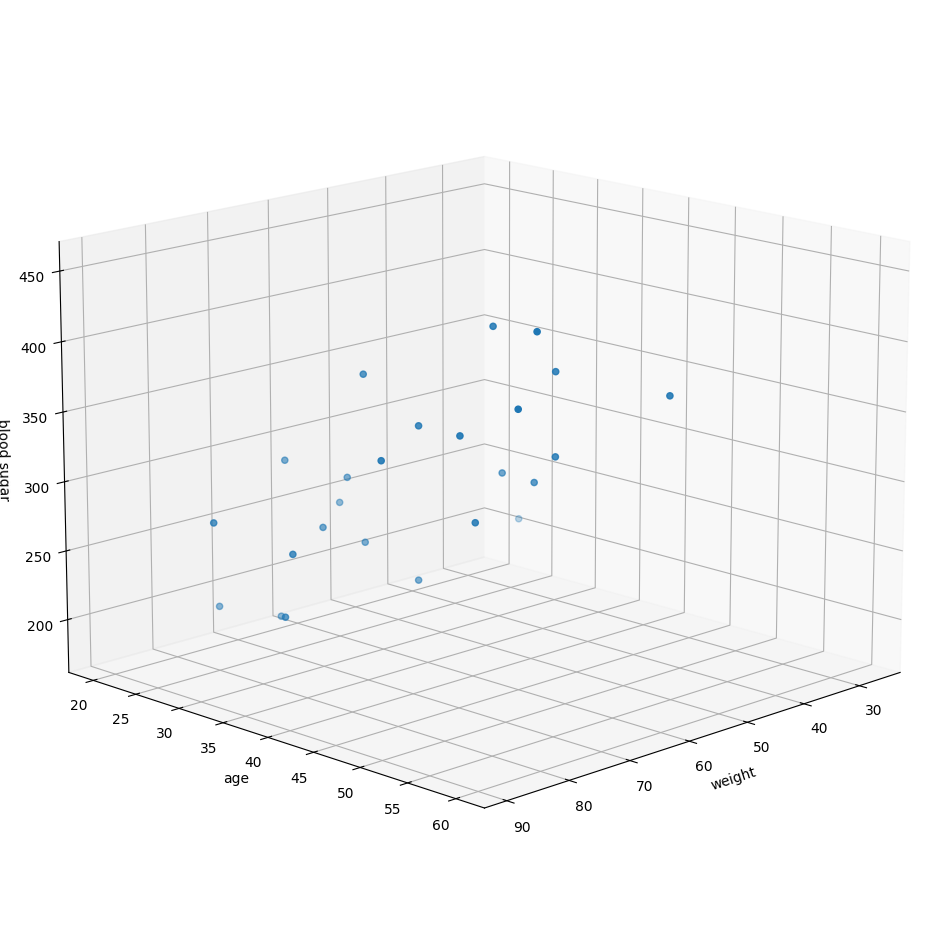

In [2]:
import matplotlib.pyplot as plt
xdata = np.array(data[:,2], dtype=np.float32)
ydata = np.array(data[:,3], dtype=np.float32)
zdata = np.array(data[:,4], dtype=np.float32)
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(xdata,ydata,zdata)
ax.set_xlabel('weight')
ax.set_ylabel('age')
ax.set_zlabel('blood sugar')
ax.view_init(15,45)
plt.show()

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
#데이터를 케라스에 맞게 변환
x_data = np.array(data[:,2:4], dtype=np.float32)
y_data = np.array(data[:,4], dtype=np.float32)

array([[84., 46.],
       [73., 20.],
       [65., 52.],
       [70., 30.],
       [76., 57.],
       [69., 25.],
       [63., 28.],
       [72., 36.],
       [79., 57.],
       [75., 44.],
       [27., 24.],
       [89., 31.],
       [65., 52.],
       [57., 23.],
       [59., 60.],
       [69., 48.],
       [60., 34.],
       [79., 51.],
       [75., 50.],
       [82., 34.],
       [59., 46.],
       [67., 23.],
       [85., 37.],
       [55., 40.],
       [63., 30.]], dtype=float32)

In [4]:
model = Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(1))
model.compile(loss='mse', optimizer='adam')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
#학습 전의 파라미터
w, b = model.get_weights()
w, b

(array([[ 0.652156 ],
        [-1.1025572]], dtype=float32),
 array([0.], dtype=float32))

In [6]:
hist = model.fit(x_data, y_data, epochs=1000)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - loss: 102884.7109
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 102815.2812
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 102745.8906
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 102676.5078
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 102607.1562
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 102537.8516
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 102468.5625
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 102399.2891
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 102330.0469
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 102260.8438
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 102191.6562
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 102122.5000
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 102053.3672
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 101984.2812


In [7]:
hist.history.keys()

dict_keys(['loss'])

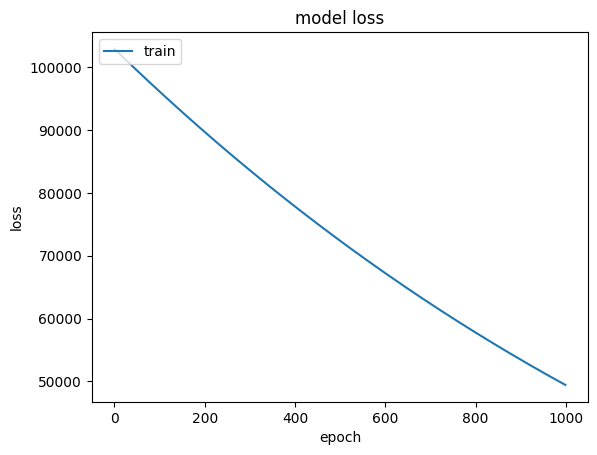

In [8]:
plt.plot(hist.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train'], loc='upper left')
plt.show()

In [13]:
 #새로운 데이터로 예측
 #체중 100kg, 40세
 #1차원 배열을 1행 2열의 2차원 배열로 변환
 model.predict(np.array([100,40]).reshape(1,2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


array([[150.58836]], dtype=float32)

In [10]:
model.predict(np.array([60,25]).reshape(1,2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[90.53929]], dtype=float32)

In [15]:
# 학습 후의 파라미터
# 가중치와 절편,편향(bias)
w, b = model.get_weights()
w, b

(array([[ 1.5691552 ],
        [-0.18114367]], dtype=float32),
 array([0.9185725], dtype=float32))

In [16]:
# linspace(start, stop, num=50, endpoint=True, retstep=False, dtype=None)
# start부터 stop의 범위에서 num개를 균일한 간격으로 데이터를 생성하고 배열을 만드는 함수
x = np.linspace(20,100,50).reshape(50,1)
y = np.linspace(10,70,50).reshape(50,1)
x2 = np.concatenate((x,y), axis=1)
#행렬곱셈
z = np.matmul(x2,w)+b

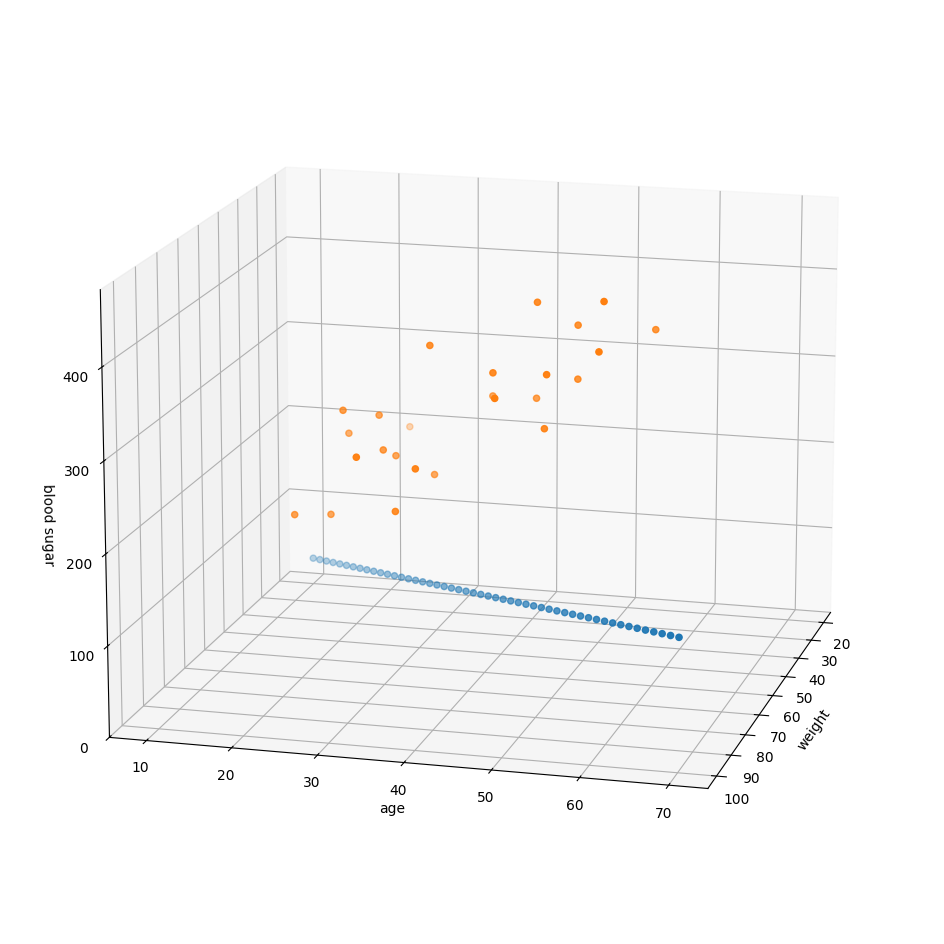

In [17]:
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111,projection='3d')
#회귀선
ax.scatter(x,y,z)
#산점도
ax.scatter(xdata,ydata,zdata)
ax.set_xlabel('weight')
ax.set_ylabel('age')
ax.set_zlabel('blood sugar')
ax.view_init(15,15)
plt.show()